# Organize various pieces of data to construct a spatialdata object

https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/sdata_from_scratch.html

data:
1. bin2cell expression and metadata (e.g. rds or h5ad)
2. H&E image
3. segmentation results


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import spatialdata as sd
import spatialdata_plot as sdp  # noqa: F401
# import squidpy as sq
from shapely.geometry import Point
from spatialdata.models import Image2DModel, ShapesModel, TableModel, Labels2DModel 
from tifffile import imread
import os
import anndata as ad
import numpy as np
import scipy as sci
import tqdm

/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
testid = "FBC128_B1" # "good"
# testid = "MBC2_1A" # "bad"

In [3]:
meta = pd.read_csv("../../processed/LNcell_meta.csv")
meta

/tmp/ipykernel_75287/3665955076.py:1: DtypeWarning: Columns (17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("../../processed/LNcell_meta.csv")


,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,object_id,bin_count,array_row,array_col,Absolute.X,Absolute.Y,...,tissue_source,sex,mutation,tumor_type,t_stage,n_stage,age,grade,recurrence,survival
0,2_1,SeuratProject,36,35,2.0,17,91.705882,167.058824,6881.299690,19545.945671,...,Lymph Node,Female,Sporadic,Benign,1b,0,87,2,Local,alive
1,8_1,SeuratProject,84,83,8.0,26,198.807692,116.576923,7076.184079,19454.032631,...,Lymph Node,Female,Sporadic,Benign,1b,0,87,2,Local,alive
2,10_1,SeuratProject,21,21,10.0,9,153.777778,66.000000,6994.216530,19362.011268,...,Lymph Node,Female,Sporadic,Benign,1b,0,87,2,Local,alive
3,24_1,SeuratProject,41,38,24.0,22,105.500000,497.045455,6906.541835,20146.453032,...,Lymph Node,Female,Sporadic,Benign,1b,0,87,2,Local,alive
4,30_1,SeuratProject,40,38,30.0,22,233.590909,187.500000,7139.513074,19583.084460,...,Lymph Node,Female,Sporadic,Benign,1b,0,87,2,Local,alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6700102,1311287_15,SeuratProject,28,27,1311287.0,5,3308.200000,2924.400000,21161.938608,36817.825486,...,Lymph Node,Male,Sporadic,Benign,1c,0,65,3,no,alive
6700103,1311415_15,SeuratProject,70,68,1311415.0,11,3342.454545,2933.636364,21285.272158,36849.988015,...,Lymph Node,Male,Sporadic,Benign,1c,0,65,3,no,alive
6700104,1311498_15,SeuratProject,30,29,1311498.0,11,2975.727273,3297.181818,19978.743087,38166.860439,...,Lymph Node,Male,Sporadic,Benign,1c,0,65,3,no,alive
6700105,1311499_15,SeuratProject,23,23,1311499.0,8,3239.000000,3283.500000,20924.160938,38109.868694,...,Lymph Node,Male,Sporadic,Benign,1c,0,65,3,no,alive


In [24]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6700107 entries, 0 to 6700106
Data columns (total 23 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Unnamed: 0     object 
 1   orig.ident     object 
 2   nCount_RNA     int64  
 3   nFeature_RNA   int64  
 4   object_id      float64
 5   bin_count      int64  
 6   array_row      float64
 7   array_col      float64
 8   Absolute.X     float64
 9   Absolute.Y     float64
 10  cropped.X      float64
 11  cropped.Y      float64
 12  id             object 
 13  tissue_source  object 
 14  sex            object 
 15  mutation       object 
 16  tumor_type     object 
 17  t_stage        object 
 18  n_stage        object 
 19  age            int64  
 20  grade          int64  
 21  recurrence     object 
 22  survival       object 
dtypes: float64(7), int64(5), object(11)
memory usage: 1.1+ GB


# Concat data

In [11]:
emeta = pd.read_csv("../../documents/sample_meta.csv")
emeta.index = emeta.Name
emeta.head()

,Name,HandE,Tumor or LN,Male or Female,BRCA1 / BRCA2 / sporadic,Benign vs malignant,T stage,N stage,Age,Grade,Recurrence?,Vital Status,shallow_seq,umi_per_8bin,Warning,Qcflag,comment
Name,,,,,,,,,,,,,,,,,
MBC14_A9,MBC14_A9,50118783_MBC14_A9,Tumor,Male,Sporadic,Malignant,2,0,75,3,no,alive,NaN,95.3,NaN,NaN,NaN
MBC15_B7,MBC15_B7,50118808_MBC15_B7,Tumor,Male,Sporadic,Malignant,2,1mi,55,3,no,alive,T,26.8,NaN,T,peripheral bias of reads
MBC9_1A,MBC9_1A,50118557_MBC9_1A,Tumor,Male,Sporadic,Malignant,1c,0,65,3,no,alive,T,35.2,High Fraction Reads Split-Mapped to Probe Set,NaN,NaN
MBC11_A4,MBC11_A4,50118613_MBC11_A4,Tumor,Male,Sporadic,Malignant,1c,0,73,3,no,deceased,NaN,21.7,NaN,T,peripheral bias of reads
MBC9_3B,MBC9_3B,50118560_MBC9_3B,LN,Male,Sporadic,Benign,1c,0,65,3,no,alive,T,42.0,NaN,NaN,NaN


In [10]:
LN_names = emeta.Name.loc[emeta.loc[:,"Tumor or LN"] == "LN"]
tumor_names = emeta.Name.loc[emeta.loc[:,"Tumor or LN"] != "LN"]

In [14]:
data_dir = "../03-segmentation/seg_dilate/"
ad_list = []
i = 0
for f in tqdm.tqdm(os.listdir(data_dir)):
    sname = f.split(".")[0]
    if sname not in LN_names:
        continue
    adata = ad.read_h5ad(data_dir+f)
    smeta = meta.loc[meta.id == sname,:]
    new_index = smeta["Unnamed: 0"].apply(lambda s: s.split("_")[0])
    new_index.name = None
    smeta.index = new_index
    ameta = adata.obs
    keep_cols = list(set(smeta.columns.tolist())-set(ameta.columns.tolist()))
    ameta = ameta.join(smeta.loc[:,keep_cols], how='left')
    adata.obs = ameta
    adata = adata[~adata.obs.id.isna(),:]
    adata.obs_names = [bc+"_"+str(i) for bc in adata.obs_names]
    ad_list.append(adata)
    i+=1

100%|██████████| 35/35 [03:19<00:00,  5.71s/it]


In [15]:
all_adata = ad.concat(ad_list, join="outer")

In [25]:
# problem columns: 'n_stage', 't_stage'
del all_adata.obs['n_stage']
del all_adata.obs['t_stage']

In [20]:
all_adata.obs.columns

Index(['object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X',
       'Absolute.Y', 'cropped.X', 'cropped.Y', 'tissue_source', 'Unnamed: 0',
       'recurrence', 'sex', 'nFeature_RNA', 'age', 'orig.ident', 'nCount_RNA',
       'tumor_type', 'mutation', 'grade', 't_stage', 'id', 'survival'],
      dtype='object')

In [26]:
all_adata.write("../../processed/LN_all_adata.h5ad")

In [27]:
adata_all = all_adata

In [ ]:
adata_all = ad.read_h5ad("../../processed/LN_all_adata.h5ad")


# SpatialData organize

## Image

needs to be np array, cyx

should I use the cropped or original H&E? for memory purposes I'd prefer the cropped

In [28]:
# hefiles = os.listdir("../03-segmentation/stardist/")
img = imread("../03-segmentation/stardist/"+testid+"he.tiff")
img = np.transpose(img, (2,0,1))

type(img)

numpy.ndarray

In [8]:
img.shape #(Y,X,C)?

(16347, 22871, 3)

In [29]:
img_for_sdata = Image2DModel.parse(data=img, scale_factors=(2, 2, 2))  # this creates 4 downscaled images as well


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           


## prepare the segmentation

In [30]:
labels = sci.sparse.load_npz("../03-segmentation/stardist/"+testid+".npz")
labels = labels.toarray()
labels = labels.astype(int)


In [55]:
# labels = labels.toarray()
# labels = np.expand_dims(labels, 0)
# labels.shape

In [31]:
lbl_for_sdata = Labels2DModel.parse(labels, scale_factors=(2, 2, 2))

INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


In [32]:
shapes_for_sdata = sd.to_polygons(lbl_for_sdata)

In [33]:
shapes_for_sdata.index = shapes_for_sdata.index.astype(int)
shapes_for_sdata.label = shapes_for_sdata.label.astype(int)
shapes_for_sdata.head()

,label,geometry
label,,
1,1,"POLYGON ((3574 1695.5, 3573 1695.5, 3572.5 169..."
2,2,"POLYGON ((2481 985.5, 2480 985.5, 2479 985.5, ..."
3,3,"POLYGON ((3236 796.5, 3235 796.5, 3234 796.5, ..."
4,4,"POLYGON ((3002 794.5, 3001.5 794, 3001 793.5, ..."
5,5,"POLYGON ((1269.5 1279, 1270 1278.5, 1270.5 127..."


## anndata

In [19]:
adata_all = ad.read_h5ad("../../processed/all_adata.h5ad")
adata_all

AnnData object with n_obs × n_vars = 2544044 × 13578
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y', 'group_lvl2', 'nFeature_RNA', 'id', 'seurat_clusters', 'sketch_snn_res.0.75', 'group_lvl3', 'orig.ident', 'group', 'leverage.score', 'predicted.id.full', 'predicted.id', 'group_lvl4', 'nCount_RNA', 'Unnamed: 0', 'predicted.id.full.score', 'group_lvl1', 'tech_cohort', 'exp_cohort', 'tissue_method', 'prediction.score.max', 'lda_kmeans_6', 'lda_kmeans_8', 'lda_kmeans_10', 'lda_kmeans_12'
    uns: 'spatial_lda', 'spatial_lda_probability'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [34]:
# adata = ad.read_h5ad("../03-segmentation/seg_dilate/bin2cell/"+testid+".h5ad")
adata = adata_all[adata_all.obs.id==testid,:]
adata

View of AnnData object with n_obs × n_vars = 291350 × 18065
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y', 'tissue_source', 'Unnamed: 0', 'recurrence', 'sex', 'nFeature_RNA', 'age', 'orig.ident', 'nCount_RNA', 'tumor_type', 'mutation', 'grade', 'id', 'survival'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [35]:
# del adata.uns["spatial"]
del adata.obsm["spatial"]
del adata.obsm["spatial_cropped_150_buffer"]
del adata.obs["Unnamed: 0"]

/tmp/ipykernel_75287/510274134.py:2: ImplicitModificationWarning: Removing element `.obsm['spatial']` of view, initializing view as actual.
  del adata.obsm["spatial"]


In [36]:
# reset the index to match the labels object?
# adata.obs_names = adata.obs.object_id.astype(np.float64) # adata index has to be string
adata.obs.object_id = adata.obs.object_id.astype(int)

In [62]:
adata

AnnData object with n_obs × n_vars = 76623 × 13578
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y', 'group_lvl2', 'nFeature_RNA', 'id', 'seurat_clusters', 'sketch_snn_res.0.75', 'group_lvl3', 'orig.ident', 'group', 'leverage.score', 'predicted.id.full', 'predicted.id', 'group_lvl4', 'nCount_RNA', 'predicted.id.full.score', 'group_lvl1', 'tech_cohort', 'exp_cohort', 'tissue_method', 'prediction.score.max', 'lda_kmeans_6', 'lda_kmeans_8', 'lda_kmeans_10', 'lda_kmeans_12', 'region', 'seg_id'
    uns: 'spatial_lda', 'spatial_lda_probability', 'spatialdata_attrs'

In [37]:
adata_for_sdata = TableModel.parse(adata)


In [38]:
adata_for_sdata.uns["spatialdata_attrs"] = {
    "region": "segs",  # name of the Shapes element we will use later (i.e. the object with centers
    # and radii of the Visium spots)
    "region_key": "region",  # column in adata.obs that will link a given obs to the elements it annotates
    "instance_key": "seg_id",  # column that matches a given obs in the table to a given circle
}
# all the rows of adata annotate the same element, called "spots" (as we declared above)
adata_for_sdata.obs["region"] = pd.Categorical(["segs"] * len(adata_for_sdata))
# need to filter shape ids to match the filtering done on the adata
adata_for_sdata.obs["seg_id"] = [idx for idx in shapes_for_sdata.index if idx in adata.obs.object_id.values]
adata_for_sdata.obs[["region", "seg_id"]]

,region,seg_id
3_12,segs,3
4_12,segs,4
7_12,segs,7
8_12,segs,8
9_12,segs,9
...,...,...
399277_12,segs,399277
399589_12,segs,399589
400073_12,segs,400073
402499_12,segs,402499


## Putting it all together!


In [39]:
sdata = sd.SpatialData(
    images={"hne": img_for_sdata},
    shapes={"segs": shapes_for_sdata},
    labels={"labels": lbl_for_sdata},
    tables={"adata": adata_for_sdata},
)
sdata

SpatialData object
├── Images
│     └── 'hne': DataTree[cyx] (3, 22947, 21144), (3, 11473, 10572), (3, 5736, 5286), (3, 2868, 2643)
├── Labels
│     └── 'labels': DataTree[yx] (22947, 21144), (11473, 10572), (5736, 5286), (2868, 2643)
├── Shapes
│     └── 'segs': GeoDataFrame shape: (403637, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (291350, 18065)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), labels (Labels), segs (Shapes)

In [70]:
# [g for g in adata.var_names if "CD20" in g]
"CD74" in adata.var_names
# adata.var_names[0:5]

True

INFO     Rasterizing image for faster rendering.                                                                   


/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `segs` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/smithd30/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


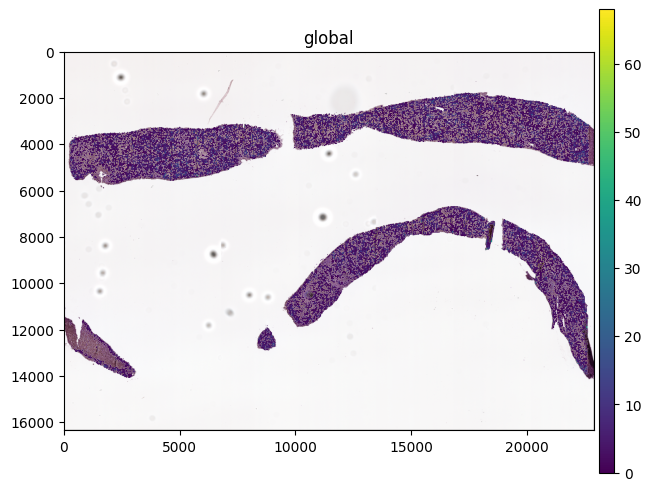

In [71]:
sdata.pl.render_images().pl.render_shapes(color="CD74").pl.show()


In [40]:
sdata.write("../../processed/spatialdata/"+testid+".zarr")

INFO     The Zarr backing store has been changed from None the new file path:                                      
         ../../processed/spatialdata/FBC128_B1.zarr                                                                


# Running all samples

In [75]:
for s in tqdm.tqdm(meta.ID_local):
    # prepare image
    img = imread("../03-segmentation/stardist/"+s+"he.tiff")
    img = np.transpose(img, (2,0,1))
    img_for_sdata = Image2DModel.parse(data=img, scale_factors=(2, 2, 2))
    # prepare segmentations
    labels = sci.sparse.load_npz("../03-segmentation/stardist/"+s+".npz")
    labels = labels.toarray()
    labels = labels.astype(int)
    lbl_for_sdata = Labels2DModel.parse(labels, scale_factors=(2, 2, 2))
    shapes_for_sdata = sd.to_polygons(lbl_for_sdata)
    shapes_for_sdata.index = shapes_for_sdata.index.astype(int)
    shapes_for_sdata.label = shapes_for_sdata.label.astype(int)
    # prepare adata
    adata = adata_all[adata_all.obs.id==s,:]
    del adata.obsm["spatial"]
    del adata.obsm["spatial_cropped_150_buffer"]
    del adata.obs["Unnamed: 0"]
    adata.obs.object_id = adata.obs.object_id.astype(int)
    adata_for_sdata = TableModel.parse(adata)
    adata_for_sdata.uns["spatialdata_attrs"] = {
        "region": "segs",  # name of the Shapes element we will use later (i.e. the object with centers
        # and radii of the Visium spots)
        "region_key": "region",  # column in adata.obs that will link a given obs to the elements it annotates
        "instance_key": "seg_id",  # column that matches a given obs in the table to a given circle
    }
    # all the rows of adata annotate the same element, called "spots" (as we declared above)
    adata_for_sdata.obs["region"] = pd.Categorical(["segs"] * len(adata_for_sdata))
    # need to filter shape ids to match the filtering done on the adata
    adata_for_sdata.obs["seg_id"] = [idx for idx in shapes_for_sdata.index if idx in adata.obs.object_id.values]
    adata_for_sdata.obs[["region", "seg_id"]]
    # put it all together
    sdata = sd.SpatialData(
        images={"hne": img_for_sdata},
        shapes={"segs": shapes_for_sdata},
        labels={"labels": lbl_for_sdata},
        tables={"adata": adata_for_sdata},
    )
    sdata.write("../../processed/spatialdata/"+s+".zarr")


  0%|          | 0/24 [00:00<?, ?it/s]

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


/home/smithd30/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3448: ImplicitModificationWarning: Removing element `.obsm['spatial']` of view, initializing view as actual.
  if await self.run_code(code, result, async_=asy):


INFO     The Zarr backing store has been changed from None the new file path:                                      
         ../../processed/spatialdata/SUR-24-06881.zarr                                                             


  4%|▍         | 1/24 [02:44<1:03:14, 164.97s/it]

...

 96%|█████████▌| 23/24 [2:09:07<04:10, 250.99s/it]

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


/home/smithd30/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3448: ImplicitModificationWarning: Removing element `.obsm['spatial']` of view, initializing view as actual.
  if await self.run_code(code, result, async_=asy):


INFO     The Zarr backing store has been changed from None the new file path:                                      
         ../../processed/spatialdata/s126_4040S5.zarr                                                              


100%|██████████| 24/24 [2:13:58<00:00, 334.95s/it]
